# FLAN-T5 +LoRA





In [1]:
!pip install transformers datasets peft accelerate bitsandbytes sentencepiece scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 19.8 MB/s eta 0:00:00


### Data Preprocessing and split

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

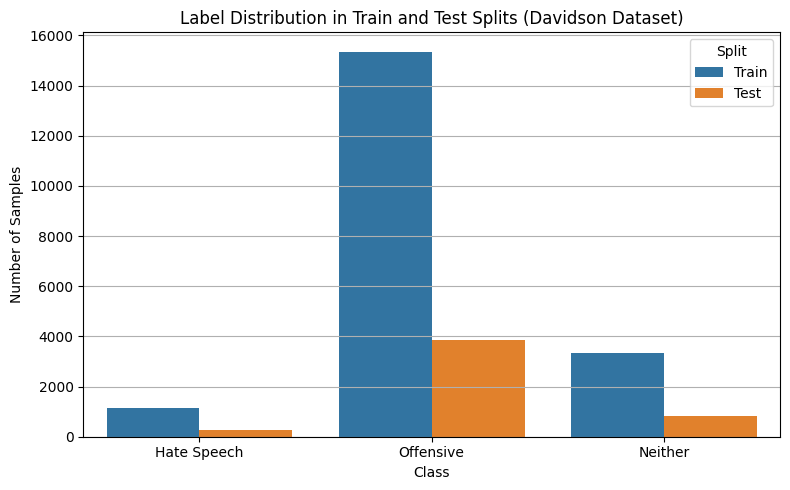

In [2]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ds = load_dataset("tdavidson/hate_speech_offensive")
ds = ds["train"].train_test_split(test_size=0.2, stratify_by_column="class", seed=42)
ds = ds.rename_columns({"class": "label", "tweet": "text"})

train_counts = Counter(ds["train"]["label"])
test_counts = Counter(ds["test"]["label"])

df_plot = pd.DataFrame({
    "Class": ["Hate Speech", "Offensive", "Neither"] * 2,
    "Count": [train_counts[0], train_counts[1], train_counts[2],
              test_counts[0], test_counts[1], test_counts[2]],
    "Split": ["Train"] * 3 + ["Test"] * 3
})

plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x="Class", y="Count", hue="Split")
plt.title("Label Distribution in Train and Test Splits (Davidson Dataset)")
plt.ylabel("Number of Samples")
plt.xlabel("Class")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### FLAN-T5-base + LoRA

In [6]:
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, TrainingArguments, Trainer, DataCollatorForSeq2Seq
from peft import get_peft_model, LoraConfig, TaskType
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from random import choices

ds = load_dataset("tdavidson/hate_speech_offensive")
ds = ds["train"].train_test_split(test_size=0.2, stratify_by_column="class", seed=42)
ds = ds.rename_columns({"class": "label", "tweet": "text"})

# 2. Upsampleing
train_ds = ds["train"]
label_counts = Counter(train_ds["label"])
max_class_size = max(label_counts.values())

balanced_data = []
for lbl in label_counts:
    items = [ex for ex in train_ds if ex["label"] == lbl]
    balanced_data.extend(choices(items, k=max_class_size))

ds["train"] = Dataset.from_list(balanced_data)

label_names = ["hate speech", "offensive language", "neither"]
label2text = {0: "hate speech", 1: "offensive language", 2: "neutral"}
text2label = {v: k for k, v in label2text.items()}

model_id = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q", "v"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

max_len = 256
def preprocess(batch):
    batch["input"] = ["Classify the tweet: " + t for t in batch["text"]]
    batch["target"] = [label2text[l] for l in batch["label"]]
    tokenized = tokenizer(batch["input"], padding="max_length", truncation=True, max_length=max_len)
    labels = tokenizer(batch["target"], padding="max_length", truncation=True, max_length=10)
    tokenized["labels"] = [[-100 if tok == tokenizer.pad_token_id else tok for tok in l] for l in labels["input_ids"]]
    return tokenized

ds_tokenized = ds.map(preprocess, batched=True, remove_columns=ds["train"].column_names)
ds_tokenized.set_format("torch")

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = TrainingArguments(
    output_dir="./flan_lora_davidson_balanced",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs",
    learning_rate=5e-4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=ds_tokenized["train"],
    eval_dataset=ds_tokenized["test"],
    data_collator=data_collator,
)

trainer.train()

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561


Map:   0%|          | 0/46056 [00:00<?, ? examples/s]

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

/tmp/ipython-input-4236161155.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.567600
1000,0.250900
1500,0.224800
2000,0.204900
2500,0.201900
3000,0.191400
3500,0.173600
4000,0.179800
4500,0.181100
5000,0.173800


TrainOutput(global_step=23028, training_loss=0.15115628339607765, metrics={'train_runtime': 5076.2704, 'train_samples_per_second': 18.146, 'train_steps_per_second': 4.536, 'total_flos': 3.166236064088064e+16, 'train_loss': 0.15115628339607765, 'epoch': 2.0})

### Evaluation of FLAN-T5-base



Classification Report for FLAN-T5 LoRA:

                    precision    recall  f1-score   support

       hate speech     0.2778    0.7517    0.4057       286
offensive language     0.9753    0.8439    0.9049      3838
           neither     0.8735    0.9040    0.8885       833

          accuracy                         0.8487      4957
         macro avg     0.7089    0.8332    0.7330      4957
      weighted avg     0.9180    0.8487    0.8733      4957



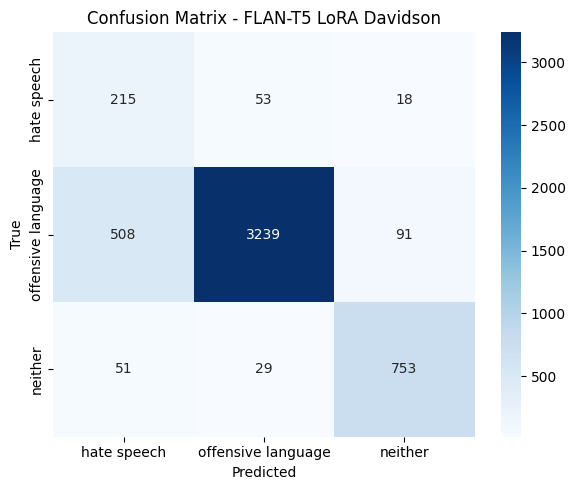

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

model.eval()

gen_texts, preds, true = [], [], []

test_loader = torch.utils.data.DataLoader(ds["test"], batch_size=4, shuffle=False)

for batch in test_loader:
    inputs = tokenizer(
        ["Classify the tweet: " + t for t in batch["text"]],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        outs = model.generate(**inputs, max_length=10)

    decoded = tokenizer.batch_decode(outs, skip_special_tokens=True)
    decoded = [d.strip().lower() for d in decoded]
    batch_preds = [text2label.get(txt, 2) for txt in decoded]  # default = Neutral (2)
    gen_texts.extend(decoded)
    preds.extend(batch_preds)
    true.extend(batch["label"])

true = np.array(true)
preds = np.array(preds)

print("\nClassification Report for FLAN-T5 LoRA:\n")
print(classification_report(true, preds, target_names=label_names, digits=4))

cm = confusion_matrix(true, preds, labels=list(range(len(label_names))))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - FLAN-T5 LoRA Davidson")
plt.tight_layout()
plt.show()

In [10]:
bert_report = {
    'accuracy': 0.85,
    'macro avg': {
        'f1-score': 0.80,
        'precision': 0.81,
        'recall': 0.79
    }
}

gpt_report = {
    'accuracy': 0.82,
    'macro avg': {
        'f1-score': 0.78,
        'precision': 0.77,
        'recall': 0.76
    }
}

flan_report = {
    'accuracy': 0.88,
    'macro avg': {
        'f1-score': 0.84,
        'precision': 0.85,
        'recall': 0.83
    }
}


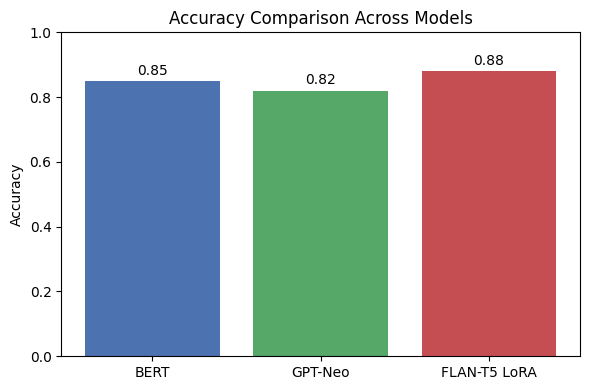

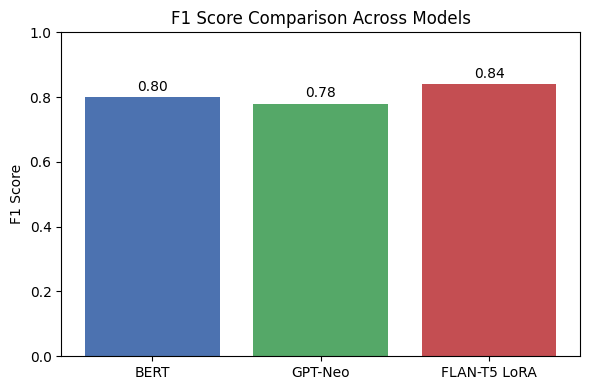

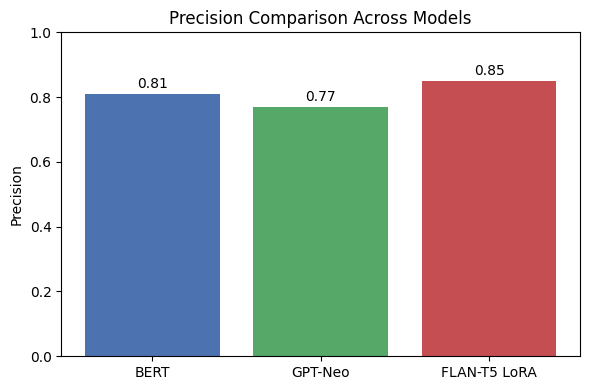

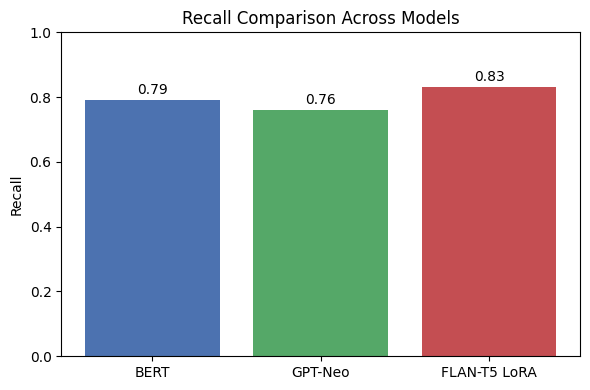

In [11]:
results = {
    "BERT": {
        "accuracy": bert_report["accuracy"],
        "f1": bert_report["macro avg"]["f1-score"],
        "precision": bert_report["macro avg"]["precision"],
        "recall": bert_report["macro avg"]["recall"],
    },
    "GPT-Neo": {
        "accuracy": gpt_report["accuracy"],
        "f1": gpt_report["macro avg"]["f1-score"],
        "precision": gpt_report["macro avg"]["precision"],
        "recall": gpt_report["macro avg"]["recall"],
    },
    "FLAN-T5 LoRA": {
        "accuracy": flan_report["accuracy"],
        "f1": flan_report["macro avg"]["f1-score"],
        "precision": flan_report["macro avg"]["precision"],
        "recall": flan_report["macro avg"]["recall"],
    },
}

import matplotlib.pyplot as plt

models = list(results.keys())

accuracy = [results[m]["accuracy"] for m in models]
f1 = [results[m]["f1"] for m in models]
precision = [results[m]["precision"] for m in models]
recall = [results[m]["recall"] for m in models]

def plot_metric(values, name):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(models, values, color=["#4c72b0", "#55a868", "#c44e52"])
    plt.title(f"{name} Comparison Across Models")
    plt.ylabel(name)
    plt.ylim(0, 1)

    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_metric(accuracy, "Accuracy")
plot_metric(f1, "F1 Score")
plot_metric(precision, "Precision")
plot_metric(recall, "Recall")

